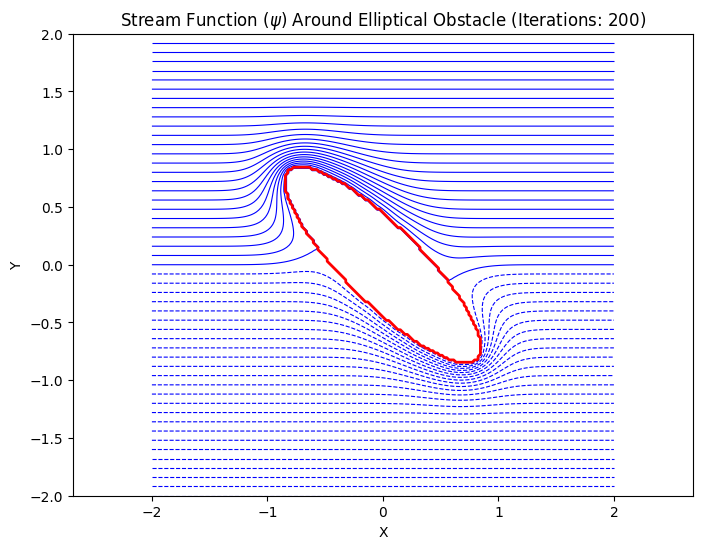

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PARAMETERS ---
N = 200           # Grid points per dimension
U_flow = 1.0     # External velocity coefficient
MAX_ITER = 200   # Iteration count for speed

# --- 2. DOMAIN SETUP ---
# Grid spans from -2 to 2
L = 4.0
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
X, Y = np.meshgrid(x, y)

# --- 3. INITIALIZATION & BOUNDARY CONDITIONS (BCs) for v ($\psi$) ---

# Initialize the stream function v with the far-field solution: v = U*y
v = U_flow * Y
v_old = v.copy()

# The Obstacle Interior Mask: 1 for interior, 0 otherwise
# Points inside this mask will be FIXED to the obstacle BC (v=0).
OBSTACLE_MASK = (X**2 + Y**2 + 1.7 * X * Y) < 0.2

# ⚠️ Enforce the Obstacle BC (v = 0) on the mask points 
v_old[OBSTACLE_MASK] = 0.0
v[OBSTACLE_MASK] = 0.0 # Also set in the working array

# The outer boundary points (i=0, N-1, j=0, N-1) retain their v = U*y value, 
# enforcing the far-field flow.

# --- 4. JACOBI ITERATION LOOP ---
for k in range(MAX_ITER):
    # Only iterate over interior grid points (1 to N-2)
    for i in range(1, N - 1):
        for j in range(1, N - 1):
            
            # Check if the point is OUTSIDE the obstacle (where the PDE holds)
            if not OBSTACLE_MASK[i, j]:
                
                # FDM: v_new is the average of the four neighbors from v_old
                v[i, j] = 0.25 * (v_old[i + 1, j] + v_old[i - 1, j] + 
                                  v_old[i, j + 1] + v_old[i, j - 1])
            # If the point IS inside the mask, we skip it. 
            # It retains the value v[i, j] = 0.0, enforcing the streamline BC.
    
    # Update the old array for the next iteration step
    v_old = v.copy()


# --- 5. VISUALIZATION ---

plt.figure(figsize=(8, 6))

# Plot streamlines (lines of constant v)
# Use a high number of levels to clearly see the flow bending
contour = plt.contour(X, Y, v, 50, colors='blue', linewidths=0.8) 

# Highlight the obstacle boundary
obstacle_boundary = plt.contour(X, Y, OBSTACLE_MASK, levels=[0.5], colors='red', linewidths=2)

plt.title(f'Stream Function ($\psi$) Around Elliptical Obstacle (Iterations: {MAX_ITER})')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.show()